In [ ]:
#IMPORT FILE FROM LOCAL NAMED VEHICLE SALES DATA
import pandas as pd

df = pd.read_csv('/content/DATASET/Vehicle Sales Data.csv', encoding='latin1')

print(df.head())
print(df.info())

   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER         ORDERDATE  \
0      10107.0             30.0      95.70              2.0    2/24/2003 0:00   
1      10121.0             34.0      81.35              5.0  05-07-2003 00:00   
2      10134.0             41.0      94.74              2.0  07-01-2003 00:00   
3      10145.0             45.0      83.26              6.0    8/25/2003 0:00   
4      10159.0             49.0     100.00             14.0  10-10-2003 00:00   

    STATUS  QTR_ID  MONTH_ID  YEAR_ID  PRODUCTLINE  ...  \
0  Shipped     1.0       2.0   2003.0  Motorcycles  ...   
1  Shipped     2.0       5.0   2003.0  Motorcycles  ...   
2  Shipped     3.0       7.0   2003.0  Motorcycles  ...   
3  Shipped     3.0       8.0   2003.0  Motorcycles  ...   
4  Shipped     4.0      10.0   2003.0  Motorcycles  ...   

                    ADDRESSLINE1 ADDRESSLINE2           CITY STATE POSTALCODE  \
0        897 Long Airport Avenue          NaN            NYC    NY      10022

In [ ]:
#TO CHECK NULL VALUES IN COLUMNS
df.isnull().sum()

,0
ORDERNUMBER,9
QUANTITYORDERED,9
PRICEEACH,9
ORDERLINENUMBER,9
ORDERDATE,9
STATUS,9
QTR_ID,9
MONTH_ID,9
YEAR_ID,9
PRODUCTLINE,9


In [ ]:
#DELETING ROWS WITH NULL VALUE IN ALL COLUMN(EMPTY ROWS)

df = df.dropna(how='all')

In [ ]:
#FILLING NULL VALUE WITH UNKNOWN

df['STATE'] = df['STATE'].fillna('Unknown')

In [ ]:
#IF YOU WANT TO FILL NUMERIC VALUES
#df['ORDERNUMBER'] = df['ORDERNUMBER'].fillna(df['ORDERNUMBER'].mean())
#df['QUANTITYORDERED'] = df['QUANTITYORDERED'].fillna(df['QUANTITYORDERED'].mean())

In [ ]:
#TO CHECK DATA TYPE

print(df.dtypes)

ORDERNUMBER                 int64
QUANTITYORDERED             int64
PRICEEACH                 float64
ORDERLINENUMBER             int64
ORDERDATE          datetime64[ns]
STATUS                     object
PRODUCTLINE                object
PRODUCTCODE                object
CUSTOMERNAME               object
STATE                      object
COUNTRY                    object
DEALSIZE                   object
CONTACTNAME                object
dtype: object


In [ ]:
#CHANGING DATA TYPE

df['ORDERNUMBER'] = df['ORDERNUMBER'].astype(int)
df['QUANTITYORDERED'] = df['QUANTITYORDERED'].astype(int)
df['ORDERLINENUMBER'] = df['ORDERLINENUMBER'].astype(int)

In [ ]:
#MERGING TO COLUMNS TO MAKE A NEW COLUMN
df['CONTACTNAME'] = df['CONTACTFIRSTNAME'] + df['CONTACTLASTNAME']

In [ ]:
#TO ADD SPACE BETWEEN THE NAME AND LAST NAME

df['CONTACTNAME'] = df['CONTACTNAME'].str.replace(r'([a-z])([A-Z])', r'\1 \2', regex=True)

In [ ]:
#DELETING UNWANTED COLUMNS

df.drop(['TERRITORY', 'POSTALCODE', 'CITY','ADDRESSLINE1', 'ADDRESSLINE2'], axis=1, inplace=True)
df.drop(['CONTACTFIRSTNAME','CONTACTLASTNAME'], axis=1, inplace=True)
df.drop(['QTR_ID', 'MONTH_ID', 'YEAR_ID'], axis=1, inplace=True)

In [ ]:
#CHANGING THE FORMAT OF ORDERDATE (MIXED VALUES)

df['ORDERDATE'] = df['ORDERDATE'].astype(str).str.strip()

date1 = pd.to_datetime(df['ORDERDATE'], format='%m/%d/%Y %H:%M', errors='coerce')
date2 = pd.to_datetime(df['ORDERDATE'], format='%d-%m-%Y %H:%M', errors='coerce')

df['ORDERDATE'] = date1.fillna(date2)

In [ ]:
#DD-MM-YYY FORMATTING

df['ORDERDATE'] = df['ORDERDATE'].dt.strftime('%d-%m-%Y')

In [ ]:
df['ORDERDATE']

,ORDERDATE
0,24-02-2003
1,05-07-2003
2,07-01-2003
3,25-08-2003
4,10-10-2003
...,...
2827,12-02-2004
2828,31-01-2005
2829,03-01-2005
2830,28-03-2005


In [ ]:
#CHNAGING DATA TYPE OF ORDERDATE FROM OBJECT TO DATETIME

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')

/tmp/ipykernel_11114/2535120564.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], errors='coerce')


In [ ]:
print(df['ORDERDATE'].dtype)

datetime64[ns]


In [ ]:
print(df.head())
print(df.info())

   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER  ORDERDATE  \
0        10107               30      95.70                2 2003-02-24   
1        10121               34      81.35                5 2003-07-05   
2        10134               41      94.74                2 2003-01-07   
3        10145               45      83.26                6 2003-08-25   
4        10159               49     100.00               14 2003-10-10   

    STATUS  PRODUCTLINE PRODUCTCODE              CUSTOMERNAME    STATE  \
0  Shipped  Motorcycles    S10_1678         Land of Toys Inc.       NY   
1  Shipped  Motorcycles    S10_1678        Reims Collectables  Unknown   
2  Shipped  Motorcycles    S10_1678           Lyon Souveniers  Unknown   
3  Shipped  Motorcycles    S10_1678         Toys4GrownUps.com       CA   
4  Shipped  Motorcycles    S10_1678  Corporate Gift Ideas Co.       CA   

  COUNTRY DEALSIZE      CONTACTNAME  
0     USA    Small          Kwai Yu  
1  France    Small     Paul Henrio

In [ ]:
#TO SAVE NEW CLEANED DATA
df.to_csv('cleaned_data.csv', index=False)

In [ ]:
#TO DOWNLOAD DATA FROM GOOGLE COLAB

from google.colab import files
df.to_csv('cleaned_data.csv', index=False)
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#PERFORMING BASIC EDA(Exploratory Data Analysis)

#CREATING SALES COLUMN

df['SALES'] = df['QUANTITYORDERED'] * df['PRICEEACH']

In [ ]:
df['SALES']

,SALES
0,2871.00
1,2765.90
2,3884.34
3,3746.70
4,4900.00
...,...
2827,2000.00
2828,2900.00
2829,4300.00
2830,2116.16


In [ ]:
#TOTAL SALES
df['SALES'].sum().astype(int)

np.int64(8290886)

In [ ]:
df['COUNTRY'].value_counts()

,count
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144
Italy,113
Finland,92
Norway,85
Singapore,79


In [ ]:
#CREATING IMPO COLUMNS FOR EDA

df['YEAR'] = df['ORDERDATE'].dt.year
df['MONTH'] = df['ORDERDATE'].dt.month
df['MONTH_NAME'] = df['ORDERDATE'].dt.month_name()
df['QUARTER'] = df['ORDERDATE'].dt.quarter

In [ ]:
#YEARLY SALES

df.groupby('YEAR')['SALES'].sum().sort_values().astype(int)

,SALES
YEAR,
2005,1479035
2003,2898149
2004,3913700


In [ ]:
#MONTHLY SALES

df.groupby('MONTH_NAME')['SALES'].sum().sort_values().astype(int).head(5)

,SALES
MONTH_NAME,
December,366155
July,418143
September,453614
June,578892
August,601689


In [ ]:
#TOP 5 CUSTOMER
df.groupby('CONTACTNAME')['SALES'].sum().sort_values(ascending=False).head(5)

,SALES
CONTACTNAME,
Diego Freyre,766195.05
Valarie Nelson,530587.19
Peter Ferguson,164575.87
Janine Labrune,153909.82
Jeff Young,151782.04


In [ ]:
#TOP PRODUCT
df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False).astype(int)

,SALES
PRODUCTLINE,
Classic Cars,2968546
Vintage Cars,1644212
Motorcycles,971086
Trucks and Buses,947355
Planes,877942
Ships,677940
Trains,203804


In [ ]:
#CORRELATION

df.corr(numeric_only=True)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,YEAR,MONTH,QUARTER
ORDERNUMBER,1.000000,0.065543,-0.002935,-0.055550,0.051042,0.904596,-0.060755,-0.059284
QUANTITYORDERED,0.065543,1.000000,0.005564,-0.018397,0.748820,0.069535,-0.038357,-0.040004
PRICEEACH,-0.002935,0.005564,1.000000,-0.020965,0.643708,-0.005938,-0.002247,0.003545
ORDERLINENUMBER,-0.055550,-0.018397,-0.020965,1.000000,-0.030057,-0.057367,0.026915,0.035557
SALES,0.051042,0.748820,0.643708,-0.030057,1.000000,0.052198,-0.031762,-0.030330
YEAR,0.904596,0.069535,-0.005938,-0.057367,0.052198,1.000000,-0.241833,-0.242376
MONTH,-0.060755,-0.038357,-0.002247,0.026915,-0.031762,-0.241833,1.000000,0.977566
QUARTER,-0.059284,-0.040004,0.003545,0.035557,-0.030330,-0.242376,0.977566,1.000000


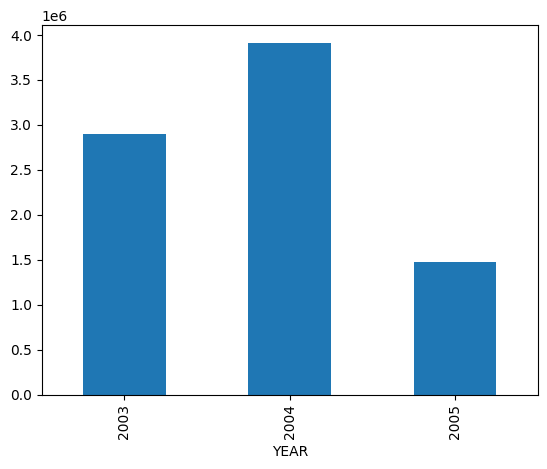

In [ ]:
#YEARLY SALES REPRESENTATION

#Sales increased from 2003 to 2005 📈

import matplotlib.pyplot as plt

df.groupby('YEAR')['SALES'].sum().plot(kind='bar')
plt.show()

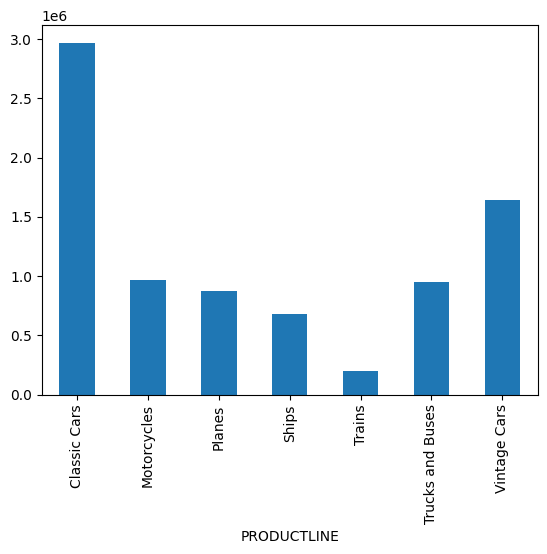

In [ ]:
#PRODUCT BASED SALES
#MOST SELLING PRODUCT IS CLASSIC CAR

import matplotlib.pyplot as plt

df.groupby('PRODUCTLINE')['SALES'].sum().plot(kind='bar')
plt.show()

<Axes: ylabel='COUNTRY'>

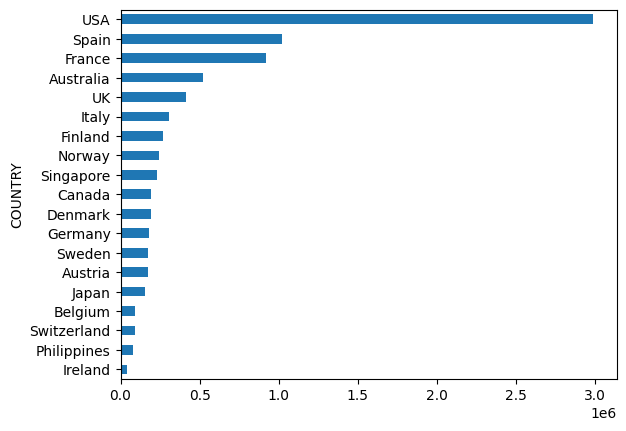

In [ ]:
#COUNTRY VISE SALE

#USA HAS THE MOST AMOUNT OF SALES

df.groupby('COUNTRY')['SALES'].sum().sort_values().plot(kind='barh')

<Axes: xlabel='YEAR'>

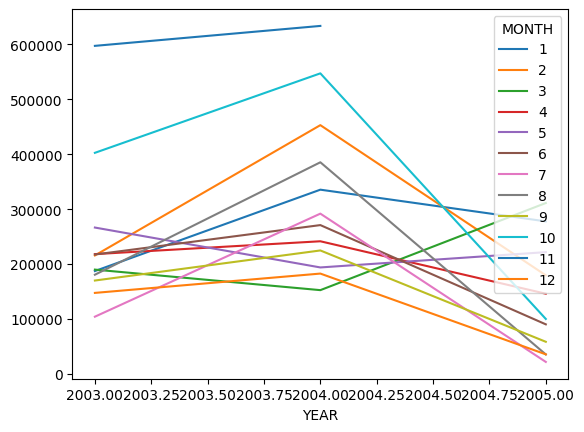

In [ ]:
#Monthly Trend

df.groupby(['YEAR','MONTH'])['SALES'].sum().unstack().plot()